# Brute Force - Divide and Conquer
Da für die Permutation n! Möglichkeiten berechnet werden müssen, in diesem Fall also 21! Varianten, wird die Rechenleistung sehr schnell überschritten. 

Eine Möglichkeit diesen Brute Force Ansatz trotzdem für das Problem anzuwenden, ist es diesen mit der Divide and Conquer Methode zu verbinden. Dafür werden die Städte in kleinere Gruppen unterteilt, zwischen denen die optimale Strecke berechent und am Ende werden die Teile zusammengefügt. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from klassen import City, distanz, neighbour

In [3]:
df = pd.read_csv('msg_standorte_deutschland.csv')
#display (df)

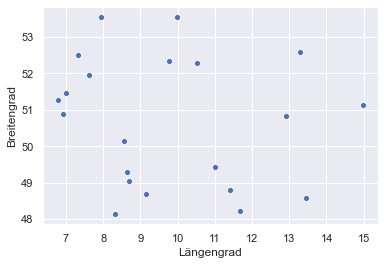

In [4]:
sns.set() 
ax = sns.scatterplot(y="Breitengrad", x="Längengrad", data=df)
#for line in range(0,df.shape[0]):
#     ax.text(df.Längengrad[line]+0.2, df.Breitengrad[line], df.msg_Standort[line], horizontalalignment='left', size='medium', color='black', weight='semibold')

Die Daten aus der Tabelle (Pandas Datenframe) werden genutzt um für jede Stadt eine Klasse City zu erzeugen, die die Kooridinaten und die Nummer der Stadt enthält.

In [15]:
cities = []

df2 = df.iloc[:11]

for row in df2.itertuples():
    new = City(row.Längengrad, row.Breitengrad, row.Nummer, row.msg_Standort)
    cities.append(new)

In [18]:
def extent(numbers):
    return max(numbers) - min(numbers)

def split_cities(cities):
    width = extent([c.x for c in cities])
    height = extent([c.y for c in cities])
    key = "x" if (width > height) else "y"
    cities = sorted(cities, key=lambda c: getattr(c, key))
    mid = len(cities) // 2
    return frozenset(cities[:mid]), frozenset(cities[mid:])

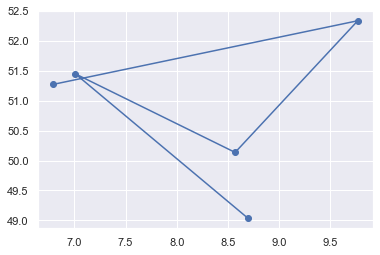

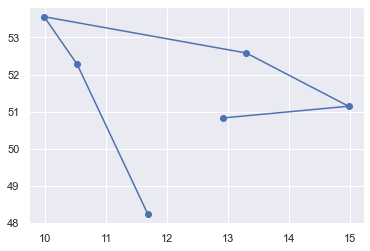

In [19]:
Cs1, Cs2 = split_cities(cities)

plt.plot([p.x for p in Cs1], [p.y for p in Cs1], "bo-")
plt.show()

plt.plot([p.x for p in Cs2], [p.y for p in Cs2], "bo-")
plt.show()